In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from pathlib import Path
import numpy as np
from torch.serialization import safe_globals
from misophonia_dataset.interface import get_data_dir
from misophonia_anc.model import MisophoniaANCNet
from misophonia_anc._utils import MisophoniaANCConfig

/build/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-05-20 12:12:32] [DEBUG] Set up print logging


In [3]:
model_dir = get_data_dir(dataset_name="model-aux-ft-label")
their_pt_file = model_dir / "checkpoints" / "theirs_39.pt"
assert their_pt_file.exists()


their_pt = torch.load(
    their_pt_file,
    map_location="cpu",
    weights_only=False,  # WARNING: This might be unsafe, only do this if you trust the source!
)


print(their_pt.keys())

dict_keys(['epoch', 'model_state_dict', 'optim_state_dict', 'lr_sched_state_dict', 'train_metrics', 'val_metrics'])


In [4]:
np.array(their_pt["val_metrics"]["signal_noise_ratio"])

array([6.95027084, 7.79854415, 7.97633686, 8.21779854, 8.86329756,
       8.83540549, 8.89713125, 8.81483981, 9.16684636, 9.14202032,
       9.35966053, 9.36693547, 9.28580033, 9.09650361, 9.39710211,
       9.36808303, 9.63827213, 9.24214809, 9.56009769, 9.27397109,
       9.54111165, 9.25406154, 9.28152523, 9.51277202, 9.50701867,
       9.68713478, 9.59957488, 9.2687908 , 9.33414229, 9.48430455,
       9.52930562, 9.75953897, 9.62541646, 9.25496926, 9.34332522,
       9.56702093, 9.52644809, 9.72040768, 9.35066989, 9.66358752])

In [5]:
np.array(their_pt["val_metrics"]["scale_invariant_signal_noise_ratio"])

array([4.57137882, 5.83157331, 5.97488623, 6.43466499, 7.12592667,
       7.02005105, 7.04716576, 7.00862066, 7.36620507, 7.29740821,
       7.52253984, 7.65990274, 7.52206932, 7.26396807, 7.64763209,
       7.49230811, 7.8127809 , 7.48675517, 7.84903163, 7.40037929,
       7.83540438, 7.25807065, 7.45066995, 7.62779623, 7.58601458,
       7.81195241, 7.89198796, 7.26751966, 7.45302494, 7.54040152,
       7.57763158, 7.88835185, 7.91732641, 7.17091929, 7.39050593,
       7.55531674, 7.483288  , 7.77081657, 7.57037277, 7.97578196])

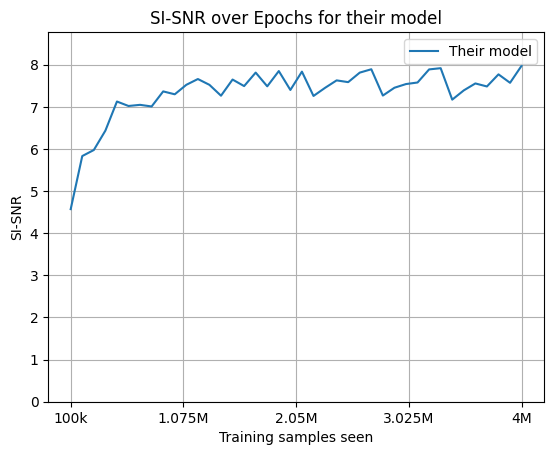

In [6]:
# Plot this
import matplotlib.pyplot as plt


def pretty_count(x: float, pos: int | None = None) -> str:
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:g}M"
    if abs(x) >= 1_000:
        return f"{x / 1_000:g}k"
    return f"{x:g}"


their_si_snr = np.array(their_pt["val_metrics"]["scale_invariant_signal_noise_ratio"])
their_samples_seen = np.arange(1, len(their_si_snr) + 1) * 100_000
plt.plot(their_samples_seen, their_si_snr, label="Their model")
plt.xlabel("Training samples seen")
plt.ylabel("SI-SNR")
plt.title("SI-SNR over Epochs for their model")
plt.ylim(0, np.max(np.array(their_pt["val_metrics"]["scale_invariant_signal_noise_ratio"])) * 1.1)
plt.grid()
# use pretty_count for x-axis ticks (there should be 10 ticks)
plt.xticks(
    ticks=np.linspace(their_samples_seen[0], their_samples_seen[-1], num=5),
    labels=[pretty_count(x) for x in np.linspace(their_samples_seen[0], their_samples_seen[-1], num=5)],
)
plt.legend()

plt.show()

In [7]:
their_pt["val_metrics"].keys()

dict_keys(['signal_noise_ratio', 'scale_invariant_signal_noise_ratio', 'loss', 'runtime'])

In [8]:
len(
    np.array(their_pt["val_metrics"]["scale_invariant_signal_noise_ratio"])
)  # I think this is how their SI-SNR grows per epoch, since epoch 39 = 40 if 0-indexed

40

In [9]:
their_pt["model_state_dict"]

{'in_conv.0.weight': tensor([[[-0.0719,  0.0494,  0.0244,  ...,  0.1908,  0.2199,  0.2813],
          [-0.0733,  0.0381,  0.0332,  ...,  0.0337,  0.0510, -0.1453]],
 
         [[ 0.0373,  0.0006,  0.0012,  ..., -0.1843,  0.1506, -0.5622],
          [ 0.0351,  0.0008, -0.0023,  ..., -0.0487,  0.0112,  0.0699]],
 
         [[ 0.0864, -0.0350, -0.0568,  ...,  0.1158,  0.2564,  0.0444],
          [-0.0224,  0.1066,  0.0541,  ...,  0.0944, -0.0693, -0.0113]],
 
         ...,
 
         [[-0.0227,  0.0112,  0.0118,  ...,  0.0081,  0.0426,  0.1036],
          [-0.0486,  0.0272,  0.0053,  ...,  0.0425,  0.0460,  0.1753]],
 
         [[-0.0897,  0.0106,  0.0099,  ...,  0.0531, -0.0484,  0.2224],
          [-0.1840, -0.0138, -0.0208,  ..., -0.0743,  0.0221,  0.1235]],
 
         [[ 0.0756, -0.0110, -0.0200,  ...,  0.1377, -0.0697, -0.2126],
          [-0.0088,  0.0093, -0.0028,  ..., -0.0020, -0.0308,  0.1725]]]),
 'label_embedding.0.weight': tensor([[ 0.4096, -0.1869,  0.5335,  ..., -0.1393, -0

In [10]:
net = MisophoniaANCNet(
    label_len=20,
    model_dim=256,
    L=32,
    # num_enc_layers=10,
    num_dec_layers=1,
    dec_buf_len=13,
    dec_chunk_size=13,
    # use_pos_enc=True,
    # conditioning="mult",
    out_buf_len=4,
)
net.load_state_dict(their_pt["model_state_dict"])

<All keys matched successfully>

In [11]:
net

MisophoniaANCNet(
  (in_conv): Sequential(
    (0): Conv1d(2, 256, kernel_size=(96,), stride=(32,), bias=False)
    (1): ReLU()
  )
  (label_embedding): Sequential(
    (0): Linear(in_features=20, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
  )
  (mask_gen): MaskNet(
    (encoder): DilatedCausalConvEncoder(
      (dcc_layers): Sequential(
        (dcc_0): _DepthwiseSeparableConv(
          (layers): Sequential(
            (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), groups=256)
            (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
            (2): ReLU()
            (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
            (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
            (5): ReLU()
          )
        )
        

In [12]:
# MisophoniaANCNet(
#   (in_conv): Sequential(
#     (0): Conv1d(2, 256, kernel_size=(96,), stride=(32,), bias=False)
#     (1): ReLU()
#   )
#   (label_embedding): Sequential(
#     (0): Linear(in_features=20, out_features=512, bias=True)
#     (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
#     (2): ReLU()
#     (3): Linear(in_features=512, out_features=256, bias=True)
#     (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
#     (5): ReLU()
#   )
#   (mask_gen): MaskNet(
#     (encoder): DilatedCausalConvEncoder(
#       (dcc_layers): Sequential(
#         (dcc_0): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_1): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(2,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_2): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(4,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_3): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(8,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_4): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(16,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_5): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(32,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_6): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(64,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_7): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(128,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_8): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(256,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#         (dcc_9): _DepthwiseSeparableConv(
#           (layers): Sequential(
#             (0): Conv1d(256, 256, kernel_size=(3,), stride=(1,), dilation=(512,), groups=256)
#             (1): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (2): ReLU()
#             (3): Conv1d(256, 256, kernel_size=(1,), stride=(1,))
#             (4): _LayerNormPermuted((256,), eps=1e-05, elementwise_affine=True)
#             (5): ReLU()
#           )
#         )
#       )
#     )
#     (decoder): CausalTransformerDecoder(
#       (unfold): Unfold(kernel_size=(26, 1), dilation=1, padding=0, stride=13)
#       (pos_enc_tgt): PositionalEncoding(
#         (dropout): Dropout(p=0.0, inplace=False)
#       )
#       (pos_enc_mem): PositionalEncoding(
#         (dropout): Dropout(p=0.0, inplace=False)
#       )
#       (tf_dec_layers): ModuleList(
#         (0): _CausalTransformerDecoderLayer(
#           (self_attn): MultiheadAttention(
#             (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
#           )
#           (multihead_attn): MultiheadAttention(
#             (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
#           )
#           (linear1): Linear(in_features=256, out_features=512, bias=True)
#           (dropout): Dropout(p=0.1, inplace=False)
#           (linear2): Linear(in_features=512, out_features=256, bias=True)
#           (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
#           (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
#           (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
#           (dropout1): Dropout(p=0.1, inplace=False)
#           (dropout2): Dropout(p=0.1, inplace=False)
#           (dropout3): Dropout(p=0.1, inplace=False)
#         )
#       )
#     )
#   )
#   (out_conv): Sequential(
#     (0): ConvTranspose1d(256, 2, kernel_size=(160,), stride=(32,), padding=(128,), bias=False)
#     (1): Tanh()
#   )
# )


def _make_adapted_net(net: MisophoniaANCNet, new_label_len: int = 8) -> MisophoniaANCNet:
    """
    Adapt the given net to have a different label length, by replacing the label embedding layer and keeping the rest of the weights.

    The label embedding should be replaced with a new one that has the same architecture but different input size, and the weights should be initialized randomly. The rest of the weights should be copied from the original net.
    """
    copied = net.state_dict()
    their_hyperparams = net.hyperparameters
    new_hyperparams = their_hyperparams.copy()
    new_hyperparams["label_len"] = new_label_len
    adapted_net = MisophoniaANCNet(**new_hyperparams)
    adapted_state_dict = adapted_net.state_dict()
    # Copy all weights except the label embedding layer
    for key in adapted_state_dict.keys():
        if key.startswith("label_embedding"):
            # skip this layer
            continue
        else:
            adapted_state_dict[key] = copied[key]
    adapted_net.load_state_dict(adapted_state_dict)
    return adapted_net

ckpt_path = model_dir / "checkpoints" / "semhear_converted_checkpoint.pt"
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
adapted_net = _make_adapted_net(net)
adapted_net.save_checkpoint(
    ckpt_path,
    epoch=0,
    global_step_train=0.0,
    global_step_val=0.0,
    val_si_snr_improvement=0.0,
    val_si_snr=0.0,
    val_loss=0.0,
    train_loss=0.0,
    ema_model=None,
)


In [13]:
# Load it from checkpoint to verify it works
loaded_adapted_net = MisophoniaANCNet.from_config(
    MisophoniaANCConfig.from_yaml(model_dir / "config.yaml"),
    checkpoint=ckpt_path,
)
